In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,mean_squared_error

In [311]:
# ! curl https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/housing.csv > /content/drive/MyDrive/DM/datasets/housing.csv


In [312]:
housing = pd.read_csv('/content/drive/MyDrive/DM/datasets/housing.csv')
housing.columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


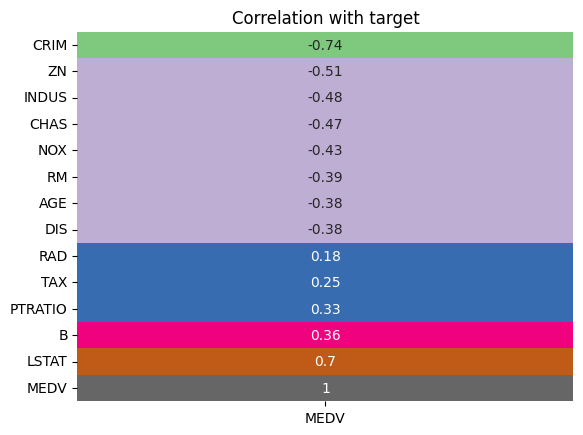

In [313]:
corr = housing.corrwith(housing["MEDV"])
sns.heatmap(corr.sort_values().values.reshape(14,1),annot=True,cbar=False,cmap=plt.cm.Accent,xticklabels=["MEDV"],yticklabels=housing.columns)
plt.title("Correlation with target")
plt.show()

In [314]:
X,y = housing.iloc[:,:-1],housing.iloc[:,-1]
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [315]:
norm = StandardScaler()
combine = pd.concat([x_train,y_train],axis="columns")
combine = pd.DataFrame(norm.fit_transform(combine),columns=housing.columns)
x_train,y_train = combine.iloc[:,:-1],combine.iloc[:,-1]
x_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.333726,0.374723,-1.050777,-0.251312,0.806430,3.090778,0.828397,-0.733619,-0.510861,-0.845022,-2.493395,0.314459,-0.921206
1,-0.382600,-0.495950,-0.059904,-0.251312,-1.224214,-0.343411,-2.113739,0.690679,-0.626614,-0.601812,0.331069,0.361143,-0.976125
2,0.271221,-0.495950,0.996158,-0.251312,-0.191536,-0.082866,-0.113649,-0.194212,1.688449,1.539616,0.786628,0.430188,-0.241056
3,-0.376565,0.048221,-0.485805,-0.251312,-0.260960,-0.185906,0.990091,1.005670,-0.510861,-0.566221,-1.491165,0.430188,0.943221
4,2.565670,-0.495950,0.996158,-0.251312,1.084125,-1.463607,0.744034,-1.038066,1.688449,1.539616,0.786628,-2.676731,1.997947


In [316]:
weights = np.ones((housing.shape[1]-1,))
bias = 0

In [317]:
ALPHA = 0.01
m = x_train.shape[0]

for i in range(300):
    y_cap = np.dot(x_train, weights) + bias

    weights = weights - (ALPHA/m) * np.dot(x_train.T, (y_cap - y_train.values))
    bias = bias - (ALPHA/m) * np.sum(y_cap - y_train.values)

    loss = (1/(2*m)) * np.power(y_cap - y_train.values, 2).sum()
loss

np.float64(0.3081762341129364)

In [318]:
y_pred = np.dot(x_test, weights) + bias
y_pred = pd.Series(y_pred,index=x_test.index)
y_pred.head()

,0
90,77.510750
97,70.567614
477,2.413410
340,78.261613
395,6.953521


In [319]:
error = mean_squared_error(y_test,y_pred)
error

2673.117819244609